# Optimal Model

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import math

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit
from mlxtend.evaluate import GroupTimeSeriesSplit
from mlxtend.evaluate.time_series import plot_splits
from sklearn.metrics import mean_squared_error, r2_score

import keras

import tensorflow as tf
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras import layers
import datetime

%load_ext tensorboard


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [110]:
# GPU Availability Check
print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.experimental.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpus)}")

# List all physical devices
physical_devices = tf.config.list_physical_devices()
print("\n📱 All Physical Devices:")
for device in physical_devices:
    print(f"  {device}")

# Check if TensorFlow is built with CUDA support
print(f"\n🔧 CUDA Support: {tf.test.is_built_with_cuda()}")

# Prevent TensorFlow from allocating all GPU memory at once
if gpus:
    try:
        # Enable memory growth for each GPU
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(f"❌ Error setting memory growth: {e}")
        
# tf.keras.mixed_precision.set_global_policy('mixed_float16')

TensorFlow version: 2.16.1
Num GPUs Available: 0

📱 All Physical Devices:
  PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')

🔧 CUDA Support: True


In [111]:
def set_reproducible(seed=12345):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    keras.utils.set_random_seed(seed)

In [112]:
dps1200 = pd.read_csv("../../data/dps1200.csv")
dps1200 = dps1200.sort_values("year", ascending=True)
print(dps1200.shape)
dps1200.head()

(1290, 414)


,year,tree,Origin,type,X2970,X2968,X2966,X2964,X2962,X2960,...,X818,X816,X814,X812,X810,X808,X806,X804,X802,X800
408,1194,Bre082,NOR,water,0.017617,0.017783,0.017949,0.018133,0.018348,0.018584,...,-0.019568,-0.019358,-0.019162,-0.018992,-0.018855,-0.018760,-0.018710,-0.018708,-0.018751,-0.018827
1016,1202,Sle074,NOR,dry,0.022443,0.022758,0.023074,0.023408,0.023755,0.024105,...,-0.023845,-0.023755,-0.023694,-0.023661,-0.023658,-0.023692,-0.023765,-0.023878,-0.024026,-0.024203
409,1206,Bre082,NOR,water,0.016759,0.016905,0.017066,0.017259,0.017477,0.017703,...,-0.019145,-0.018927,-0.018732,-0.018562,-0.018425,-0.018331,-0.018287,-0.018293,-0.018340,-0.018420
1017,1211,Sle074,NOR,dry,0.021679,0.022010,0.022333,0.022669,0.023019,0.023379,...,-0.022540,-0.022422,-0.022334,-0.022283,-0.022271,-0.022302,-0.022381,-0.022508,-0.022674,-0.022868
410,1216,Bre082,NOR,water,0.017110,0.017286,0.017470,0.017686,0.017928,0.018177,...,-0.019800,-0.019588,-0.019402,-0.019246,-0.019122,-0.019033,-0.018987,-0.018990,-0.019036,-0.019116


In [113]:
dpa = pd.read_csv("../../data/dpa.csv")
dpa = dpa.sort_values("year", ascending=True)
print(dpa.shape)
dpa.head()

(1652, 414)


,year,origin,Jahr,X3996,X2970,X2968,X2966,X2964,X2962,X2960,...,X818,X816,X814,X812,X810,X808,X806,X804,X802,X800
1645,-1256,HST,-1256,0.004886,0.017064,0.017113,0.017169,0.017240,0.017326,0.017425,...,-0.019659,-0.019528,-0.019414,-0.019324,-0.019263,-0.019233,-0.019233,-0.019259,-0.019302,-0.019355
1644,-1248,HST,-1248,0.006497,0.017340,0.017409,0.017486,0.017574,0.017677,0.017800,...,-0.020023,-0.019873,-0.019741,-0.019632,-0.019556,-0.019515,-0.019510,-0.019536,-0.019588,-0.019657
1643,-1238,HST,-1238,0.007469,0.018766,0.018888,0.019015,0.019147,0.019292,0.019449,...,-0.020777,-0.020658,-0.020557,-0.020476,-0.020419,-0.020390,-0.020390,-0.020417,-0.020466,-0.020528
1642,-1228,HST,-1228,0.006979,0.017259,0.017386,0.017524,0.017670,0.017822,0.017980,...,-0.020601,-0.020477,-0.020373,-0.020292,-0.020236,-0.020210,-0.020215,-0.020246,-0.020298,-0.020365
1641,-1218,HST,-1218,0.006883,0.017824,0.017947,0.018080,0.018215,0.018356,0.018515,...,-0.020728,-0.020569,-0.020432,-0.020323,-0.020250,-0.020215,-0.020219,-0.020258,-0.020327,-0.020415


In [114]:
daa = pd.read_csv("../../data/daa.csv")
daa = daa.sort_values("year", ascending=True)
print(daa.shape)
daa.head()

(775, 414)


,year,origin,Jahr,X3996,X2970,X2968,X2966,X2964,X2962,X2960,...,X818,X816,X814,X812,X810,X808,X806,X804,X802,X800
15,1249,BHN,1249,0.010141,0.016013,0.016305,0.016595,0.016886,0.017192,0.017515,...,-0.019834,-0.019692,-0.019571,-0.019473,-0.019406,-0.019377,-0.019393,-0.019455,-0.019558,-0.019690
16,1259,BHN,1259,0.006478,0.016792,0.017082,0.017375,0.017676,0.017988,0.018312,...,-0.018187,-0.018026,-0.017892,-0.017787,-0.017716,-0.017683,-0.017695,-0.017755,-0.017860,-0.018000
17,1269,BHN,1269,0.006970,0.017024,0.017385,0.017742,0.018102,0.018468,0.018839,...,-0.018914,-0.018765,-0.018647,-0.018561,-0.018512,-0.018510,-0.018561,-0.018659,-0.018797,-0.018969
18,1279,BHN,1279,0.009484,0.015401,0.015687,0.015979,0.016283,0.016604,0.016943,...,-0.019576,-0.019445,-0.019330,-0.019237,-0.019171,-0.019138,-0.019143,-0.019189,-0.019275,-0.019395
19,1280,BHN,1280,0.007507,0.015928,0.016148,0.016385,0.016637,0.016900,0.017179,...,-0.018113,-0.017934,-0.017778,-0.017652,-0.017562,-0.017514,-0.017512,-0.017564,-0.017668,-0.017811


In [115]:
frames = [dps1200, dpa, daa]

result = pd.concat(frames)
result = result.sort_values("year", ascending=True)
result.head()

#result = dps1200  # comment out to use all datasets

,year,tree,Origin,type,X2970,X2968,X2966,X2964,X2962,X2960,...,X812,X810,X808,X806,X804,X802,X800,origin,Jahr,X3996
1645,-1256,NaN,NaN,NaN,0.017064,0.017113,0.017169,0.017240,0.017326,0.017425,...,-0.019324,-0.019263,-0.019233,-0.019233,-0.019259,-0.019302,-0.019355,HST,-1256.0,0.004886
1644,-1248,NaN,NaN,NaN,0.017340,0.017409,0.017486,0.017574,0.017677,0.017800,...,-0.019632,-0.019556,-0.019515,-0.019510,-0.019536,-0.019588,-0.019657,HST,-1248.0,0.006497
1643,-1238,NaN,NaN,NaN,0.018766,0.018888,0.019015,0.019147,0.019292,0.019449,...,-0.020476,-0.020419,-0.020390,-0.020390,-0.020417,-0.020466,-0.020528,HST,-1238.0,0.007469
1642,-1228,NaN,NaN,NaN,0.017259,0.017386,0.017524,0.017670,0.017822,0.017980,...,-0.020292,-0.020236,-0.020210,-0.020215,-0.020246,-0.020298,-0.020365,HST,-1228.0,0.006979
1641,-1218,NaN,NaN,NaN,0.017824,0.017947,0.018080,0.018215,0.018356,0.018515,...,-0.020323,-0.020250,-0.020215,-0.020219,-0.020258,-0.020327,-0.020415,HST,-1218.0,0.006883


In [116]:
features = result.iloc[:, 4:414].values
labels = result.iloc[:, 0].values
print(features.shape)

(3717, 410)


In [117]:
def convertToDecade(y:int) -> int: 
    return int(str(y)[:3])

def calculate_sample_weights(y_train):

    decades = [convertToDecade(year) for year in y_train]

    unique_decades, counts = np.unique(decades, return_counts=True)
    total_samples = len(y_train)
    
    weights = {}
    for decade, count in zip(unique_decades, counts):
        weights[decade] = 1 - count/total_samples

    sample_weights = []
    for year in y_train:
        sample_weights.append(weights[convertToDecade(year)])
        
    return np.array(sample_weights)            


In [118]:
# Add learning rate scheduling callback
def create_lr_scheduler():
    # reduces LR when validation loss plateaus
    scheduler = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=80,
        min_lr=1e-6,
        verbose=1
    )
    return scheduler

In [119]:
def create_optimizer():
    # opt = keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-5)  # causes underfitting?
    opt = keras.optimizers.Adam(learning_rate=0.001)
    return opt

In [120]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation, Add,
    MaxPooling1D, GlobalAveragePooling1D, Dense, Concatenate
)

# best so far at loss around 3e-4
# praise be Gemini Pro 2.5, https://g.co/gemini/share/e3f26b1e78f3
def inception_residual_module(input_tensor, num_filters):
    """
    The core building block of the network. It processes data at multiple scales
    and includes a residual connection for stable training.
    """
    # Use a 1x1 convolution as a "bottleneck" to reduce computational cost
    bottleneck = Conv1D(filters=num_filters // 4, kernel_size=1, padding='same', use_bias=False)(input_tensor)
    bottleneck = BatchNormalization()(bottleneck)
    bottleneck = Activation('relu')(bottleneck)

    # --- Parallel branches for multi-scale feature extraction ---
    # Small kernel for sharp peaks
    branch1 = Conv1D(filters=num_filters // 4, kernel_size=3, padding='same', use_bias=False)(bottleneck)

    # Medium kernel for wider features
    branch2 = Conv1D(filters=num_filters // 2, kernel_size=7, padding='same', use_bias=False)(bottleneck)
    
    # Large kernel for broad shapes
    branch3 = Conv1D(filters=num_filters // 4, kernel_size=11, padding='same', use_bias=False)(bottleneck)

    # Combine the features from all branches
    concatenated = Concatenate()([branch1, branch2, branch3])
    
    # Final 1x1 convolution to restore the desired number of filters
    final_conv = Conv1D(filters=num_filters, kernel_size=1, padding='same', use_bias=False)(concatenated)
    final_conv = BatchNormalization()(final_conv)

    # --- Residual Connection ---
    # Add the original input to the output of the convoluted path.
    # This helps prevent vanishing gradients in a deep network.
    if input_tensor.shape[-1] != num_filters:
        shortcut = Conv1D(filters=num_filters, kernel_size=1, padding='same', use_bias=False)(input_tensor)
        shortcut = BatchNormalization()(shortcut)
    else:
        shortcut = input_tensor
        
    output = Add()([final_conv, shortcut])
    output = Activation('relu')(output)
    
    return output

def build_wood_age_incepresnet(input_dim):
    """
    Constructs the full Inception-Residual model.
    """

    inputs = Input(shape=(input_dim, 1))

    # --- Stem: Initial Feature Extraction ---
    # A standard convolution to process the raw input and reduce dimensionality.
    x = Conv1D(filters=64, kernel_size=13, strides=2, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

    # --- Core Blocks: Deep Feature Learning ---
    # Stack the custom modules to learn increasingly complex features.
    x = inception_residual_module(x, num_filters=128)
    x = inception_residual_module(x, num_filters=128)
    x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

    x = inception_residual_module(x, num_filters=256)
    x = inception_residual_module(x, num_filters=256)
    x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

    # --- Head: Final Prediction ---
    # Global Average Pooling is the key to fighting overfitting.
    # It creates one feature per filter, summarizing the entire spectrum.
    x = GlobalAveragePooling1D()(x)
    
    # A small dense head for the final regression output.
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1, activation='linear', name='age_output')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss=tf.keras.losses.Huber(), optimizer=create_optimizer(), metrics=['mean_absolute_error', 'root_mean_squared_error'])
    model.summary()

    return model, 'incepresnet'

# Crossvalidation

Since NN training involves random sampling and weights initialization (in this case), it is usefull to use cross-validation.

In [121]:
## Compute error metrics
def error_metrics(y_true_train, y_predicted_train, y_true_test, y_predicted_test):
    rmse_train = np.sqrt(mean_squared_error(y_true_train, y_predicted_train))
    rmse_test = np.sqrt(mean_squared_error(y_true_test, y_predicted_test))
    R2_train= r2_score(y_true_train, y_predicted_train)
    R2_test= r2_score(y_true_test, y_predicted_test)
    h = tf.keras.losses.Huber()
    hub_train = h(y_true_train, y_predicted_train).numpy()
    hub_test = h(y_true_test, y_predicted_test).numpy()
    
    print('*********** Benchmark results ***********\n')
    print(f"R2    (Train/Test) = {R2_train:.3f} / {R2_test:.3f}")
    print(f"RMSE  (Train/Test) = {rmse_train:.3f} / {rmse_test:.3f}")
    print(f"Huber (Train/Test) = {hub_train:.3f} / {hub_test:.3f}")

    return (rmse_train, rmse_test, R2_train, R2_test, hub_train, hub_test)

class ModelWithData:
    def __init__(self, history, train_x, train_label, train_predicted, test_x, test_label, test_predicted, score:float, model) -> None:
        self.history = history
        self.train_x = train_x
        self.train_label = train_label
        self.train_predicted = train_predicted
        self.test_x = test_x
        self.test_label = test_label
        self.test_predicted = test_predicted
        self.score = score
        self.model = model

    def isBetter(self, otherScore: float) -> bool:
        return otherScore < 0 or (self.score >= 0 and self.score <= otherScore)

EMPTY_MWD = ModelWithData(None, 0, 0, 0, 0, 0, 0, -1, None)

In [122]:
def calculate_groups(years, years_in_group=100):
    groups = np.zeros(len(years))

    for i in range(len(years)):
        groups[i] = years[i] // years_in_group
    
    print("Groups:")
    print(groups)
    return groups

In [123]:
class HarmonizedTimeSplit:
    def __init__(self, validation_portion=0.1, random_seed=12345):
        self._validation_portion = validation_portion
        self._random_seed = random_seed
        self._random = random.Random(random_seed)

    def split(self, X, y = None, groups = None):

        if groups is None:
            raise ValueError("The groups should be specified")
        
        self._random = random.Random(self._random_seed)
        group_dict = self._calculate_group_indices(groups)
        train_indices = []
        test_indices = []

        for group_start, group_end in group_dict.values():
            group_indices = []

            for index in range(group_start, group_end):
                group_indices.append(index)
            
            self._random.shuffle(group_indices)

            validation_end = math.floor(len(group_indices)*self._validation_portion)

            if validation_end <= 0:
                train_indices.extend(group_indices)
            else:
                test_indices.extend(group_indices[:validation_end])
                train_indices.extend(group_indices[validation_end:])

        yield np.asarray(sorted(train_indices)), np.asarray(sorted(test_indices))

        
    def _calculate_group_indices(self, groups) -> dict[str, tuple[int,int]]:
        group_dict = {}
        current_group = None

        for index in range(len(groups)):
            group = str(groups[index])

            if group in group_dict:
                if group != current_group:
                    raise ValueError(f"The groups should be specified in consequtive order. Found group '{group}' again at index {index}")
            else:
                if current_group is not None:
                    (current_group_start, current_group_end) = group_dict[current_group]
                    group_dict[current_group] = (current_group_start, index)
                
                current_group = group
                group_dict[group] = (index, len(groups))

        return group_dict

    def plot_splits(self, groups):
        for train_indices, test_indices in self.split(None, None, groups):
            self._plot_split(train_indices, test_indices, groups)
    
    def _plot_split(self, train_indices, test_indices, groups):
        group_dict = self._calculate_group_indices(groups)

        train_in_group = np.zeros(len(group_dict))
        test_in_group = np.zeros(len(group_dict))
        groups = sorted(group_dict.keys())

        for group_index, group_name in enumerate(groups):
            (group_start, group_end) = group_dict[group_name]
            train_in_group[group_index] = self._count_in_group(train_indices, group_start, group_end)
            test_in_group[group_index] = self._count_in_group(test_indices, group_start, group_end)

        x_values = np.arange(len(groups))
        width = 0.33

        rects = plt.bar(x_values, train_in_group, width, color='k', label='Train')
        plt.bar_label(rects, padding=3)
        rects = plt.bar(x_values + width, test_in_group, width, color='r', label='Test')
        plt.bar_label(rects, padding=3)

        # Labels, legend, and title
        plt.xlabel('Groups')
        plt.xticks(x_values + width/2, groups)
        plt.ylabel('Sample Count')
        plt.legend()
        plt.title('Distribution of Train vs Test in Split')

        # Show the plot
        plt.show()
    
    def _count_in_group(self, indices, group_start, group_end):
        count = 0
        for train_index in indices:
            if train_index >= group_start and train_index < group_end:
                count += 1
            elif train_index >= group_end:
                break

        return count


Groups:
[-13. -13. -13. ...  20.  20.  20.]


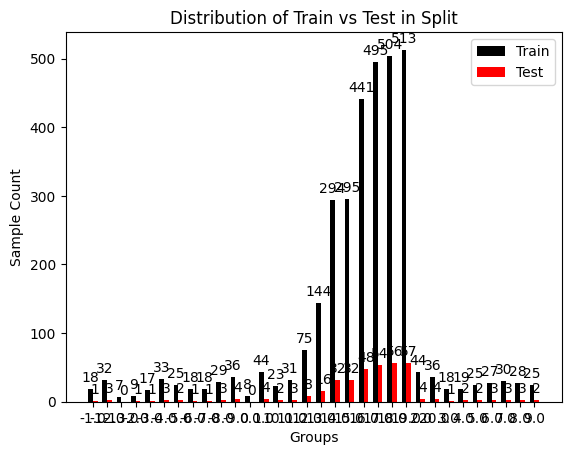

In [124]:
hts = HarmonizedTimeSplit(validation_portion=0.1)
y = np.array(labels)
groups = calculate_groups(y, 100)
hts.plot_splits(groups)

In [125]:
def evaluations_of_models(features, labels, seed=12345, epochs=100, years_in_group=100, validation_portion=0.01):

    # batch_size = 128
    batch_size = 45
    set_reproducible(seed)

    x = np.array(features, dtype=np.float32)  # Convert to float32 upfront
    y_int = np.array(labels)
    y = y_int.astype(np.float32)  # Use float32
    
    groups = calculate_groups(y_int, years_in_group)
    input_dim = 410
    
    # Ensure proper shape for CNN (add channel dimension if needed)
    if x.ndim == 2:
        x = x.reshape((x.shape[0], x.shape[1], 1))
    
    x_full_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
    y_full_tensor = tf.convert_to_tensor(y, dtype=tf.float32)

    model, name = build_wood_age_incepresnet(input_dim)

    # Define the number of folds for Cross-Validation
    hts = HarmonizedTimeSplit(validation_portion=validation_portion)
    hts.plot_splits(groups)

    scores_train = { "rmse": [], "r2": [], "huber": []}
    scores_test = { "rmse": [], "r2": [], "huber": []}

    bestMwd = EMPTY_MWD

    tensorboard_base_dir = "tb_logs"

    all_mwds = []
    
    for train_index, test_index in hts.split(x, y, groups):
        set_reproducible(seed)

        tensorboard_log_dir = f"{tensorboard_base_dir}/{name}/{seed}"
        tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=tensorboard_log_dir)
        
        # Early stopping to prevent overfitting
        # early_stopping = tf.keras.callbacks.EarlyStopping(
        #     monitor='val_loss',
        #     patience=300,
        #     restore_best_weights=True,
        #     verbose=1
        # )
        
        x_train_tensor = tf.gather(x_full_tensor, train_index)
        y_train_tensor = tf.gather(y_full_tensor, train_index)
        x_test_tensor = tf.gather(x_full_tensor, test_index)
        y_test_tensor = tf.gather(y_full_tensor, test_index)
        x_train = x[train_index]
        y_train = y[train_index]
        x_test = x[test_index]
        y_test = y[test_index]
        
        sample_weight = calculate_sample_weights(y_int[train_index])
        sample_weight_tensor = tf.convert_to_tensor(sample_weight, dtype=tf.float32)
        
        weight_dataset = tf.data.Dataset.from_tensor_slices(sample_weight_tensor)
        
        train_dataset_with_weights = tf.data.Dataset.zip((
            tf.data.Dataset.from_tensor_slices(x_train_tensor),
            tf.data.Dataset.from_tensor_slices(y_train_tensor), 
            weight_dataset
        ))
        
        train_dataset_with_weights = train_dataset_with_weights.shuffle(buffer_size=len(train_index))
        train_dataset_with_weights = train_dataset_with_weights.batch(batch_size)
        train_dataset_with_weights = train_dataset_with_weights.prefetch(tf.data.AUTOTUNE)

        val_dataset = tf.data.Dataset.from_tensor_slices((x_test_tensor, y_test_tensor))
        val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
        
        callbacks = [tensorboard_callback]
        callbacks += [create_lr_scheduler()]
        # callbacks += [early_stopping]
        
        history = model.fit(train_dataset_with_weights,
                            epochs=epochs,
                            validation_data=val_dataset,
                            verbose=1,
                            callbacks=callbacks)
        
        #evaluation_results = model.evaluate(val_dataset, verbose=0)
        #evaluation_labels = model.metrics_names

        #for j in range(len(evaluation_results)):
        #    print(f'{evaluation_labels[j]}: {evaluation_results[j]}')

        train_pred_dataset = tf.data.Dataset.from_tensor_slices(x_train_tensor).batch(batch_size)
        test_pred_dataset = tf.data.Dataset.from_tensor_slices(x_test_tensor).batch(batch_size)
        train_pred = model.predict(train_pred_dataset, verbose=0)
        test_pred = model.predict(test_pred_dataset, verbose=0)

        train_pred = train_pred.flatten()  # Remove extra dimensions
        test_pred = test_pred.flatten()

        (rmse_train, rmse_test, r2_train, r2_test, huber_train, huber_test) = error_metrics(y_train, train_pred, y_test, test_pred)

        mwd = ModelWithData(history, x_train, y_train, train_pred, x_test, y_test, test_pred, rmse_train, model)

        all_mwds.append(mwd)

        if mwd.isBetter(bestMwd.score):
            bestMwd = mwd

        scores_train["rmse"].append(rmse_train)
        scores_train["r2"].append(r2_train)
        scores_train["huber"].append(huber_train)

        scores_test["rmse"].append(rmse_test)
        scores_test["r2"].append(r2_test)
        scores_test["huber"].append(huber_test)

    ## clear session 
    tf.keras.backend.clear_session()

    scores_train_mean = {}
    scores_test_mean = {}
    num_model = len(scores_train["rmse"])

    for metric in scores_train.keys():
        scores_train_mean[metric] = np.mean(scores_train[metric])
        scores_test_mean[metric] = np.mean(scores_test[metric])
        print(f'Train: {metric} (mean of {num_model} models)= {scores_train_mean[metric]} \nTest: {metric} (mean of {num_model} models)= {scores_test_mean[metric]}')
    
    return (bestMwd, all_mwds)

Using seed 3173
Groups:
[-13. -13. -13. ...  20.  20.  20.]


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 410, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 205, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 205, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 205, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 103, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 103, 32)   │      2,048 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 103, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 103, 32)   │      3,072 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 103, 64)   │     14,336 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 103, 32)   │     11,264 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 103, 128)  │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 103, 128)  │     16,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 103, 128)  │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 103, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 103, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 103, 32)   │      4,096 │ activation_2[0][

 Total params: 545,217 (2.08 MB)

 Trainable params: 542,401 (2.07 MB)

 Non-trainable params: 2,816 (11.00 KB)

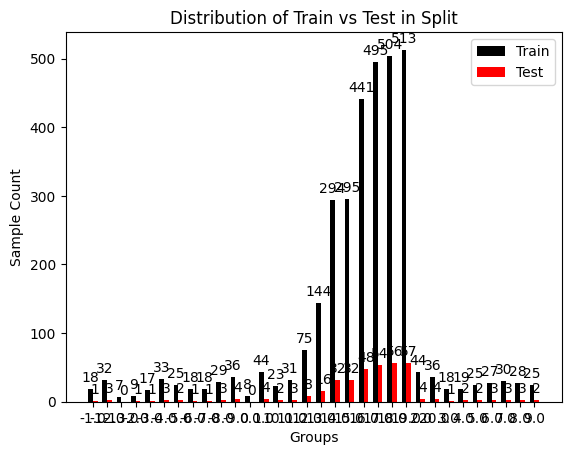

Epoch 1/377
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 1409.8506 - mean_absolute_error: 1428.1735 - root_mean_squared_error: 1497.4187 - val_loss: 1421.4761 - val_mean_absolute_error: 1417.6211 - val_root_mean_squared_error: 1472.3441 - learning_rate: 0.0010
Epoch 2/377
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 574.3335 - mean_absolute_error: 581.4846 - root_mean_squared_error: 685.6891 - val_loss: 1369.2521 - val_mean_absolute_error: 1365.4888 - val_root_mean_squared_error: 1418.2876 - learning_rate: 0.0010
Epoch 3/377
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 252.4641 - mean_absolute_error: 254.7771 - root_mean_squared_error: 470.7106 - val_loss: 1248.0627 - val_mean_absolute_error: 1244.5582 - val_root_mean_squared_error: 1291.9037 - learning_rate: 0.0010
Epoch 4/377
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 228.6439 - mean_absolute_error: 230.7789 - root_mean_squared_error: 427.1259 - val_loss: 1005.2216 - val_mean_absolute_error: 1002.3578 - val_root_mean_sq

In [126]:
seeds = [3173 ]#, 6113, 1]
all_mwds : list[ModelWithData] = []

for seed in seeds:
    print(f"Using seed {seed}")
    (bestMwd, all_mwds_of_run) = evaluations_of_models(features, labels, seed=seed, epochs=377, years_in_group=100, validation_portion=0.1)
    all_mwds.extend(all_mwds_of_run)

# epoch 376 rmse 74/102


In [127]:
def plot_model_performance(mwd: ModelWithData):
    # undo log transformation for better interpretability
    x_train_label = mwd.train_label
    x_test_label = mwd.test_label
    y_train_predicted = mwd.train_predicted
    y_test_predicted = mwd.test_predicted
    
    # Create an array of x-values ranging from the minimum to maximum of the data
    x_values = np.linspace(min(x_train_label), max(x_train_label), 100)

    # Plot the line of equality (y=x)
    plt.plot(x_values, x_values, color='blue', linestyle='--', label='Y = X line')
    plt.grid(visible=True)

    # Scatter plot for predicted values
    plt.scatter(x_train_label, y_train_predicted, c='k', label='Train Labels')
    plt.scatter(x_test_label, y_test_predicted, c='r', label='Test Labels')

    # Labels, legend, and title
    plt.xlabel('True Labels')
    plt.ylabel('Predicted Labels')
    plt.legend()
    plt.title('Scatter Plot of True vs Predicted Labels with Line of Equality')

    # Show the plot
    plt.show()

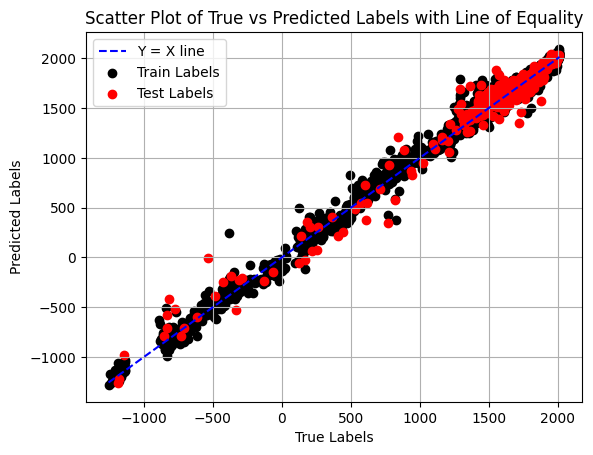

In [128]:
bestMwd = EMPTY_MWD

for mwd in all_mwds:
    if mwd.isBetter(bestMwd.score):
            bestMwd = mwd

    plot_model_performance(mwd)

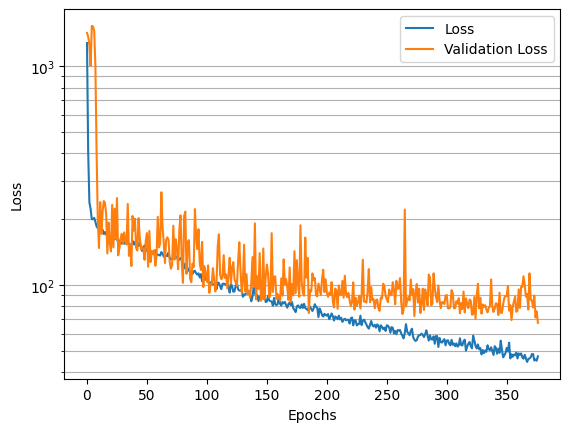

In [129]:
plt.plot(bestMwd.history.history['loss'], label='Loss')
plt.plot(bestMwd.history.history['val_loss'], label='Validation Loss')

plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.grid(visible=True, which='both', axis='y')
plt.legend()
# ax2 = plt.gca().twinx()
# ax2.plot(bestMwd.history.history['learning_rate'], color='r')
# ax2.set_ylabel('Learning Rate',color='r')

Eval_of_model = plt.legend()

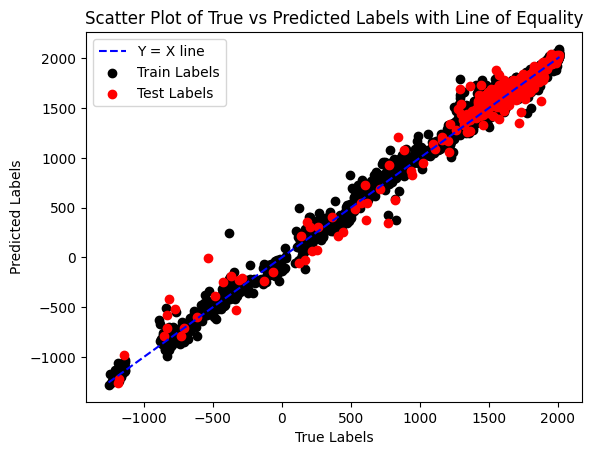

In [130]:
# undo log transformation for better interpretability
x_train_label = bestMwd.train_label
x_test_label = bestMwd.test_label
y_train_predicted = bestMwd.train_predicted
y_test_predicted = bestMwd.test_predicted

# Create an array of x-values ranging from the minimum to maximum of the data
x_values = np.linspace(min(labels), max(labels), 100)

# Plot the line of equality (y=x)
plt.plot(x_values, x_values, color='blue', linestyle='--', label='Y = X line')

# Scatter plot for predicted values
plt.scatter(x_train_label, y_train_predicted, c='k', label='Train Labels')
plt.scatter(x_test_label, y_test_predicted, c='r', label='Test Labels')

# Labels, legend, and title
plt.xlabel('True Labels')
plt.ylabel('Predicted Labels')
plt.legend()
plt.title('Scatter Plot of True vs Predicted Labels with Line of Equality')

# Show the plot
plt.show()

## Save the model

In [131]:
bestMwd.model.save('all_temp_sub_model.keras')

# Evaluation of the restored model

In [132]:
all_temp_sub_model = tf.keras.models.load_model('all_temp_sub_model.keras')

# Show the model architecture
all_temp_sub_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 410, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 205, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 205, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 205, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 103, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 103, 32)   │      2,048 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 103, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 103, 32)   │      3,072 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 103, 64)   │     14,336 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 103, 32)   │     11,264 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 103, 128)  │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 103, 128)  │     16,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 103, 128)  │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 103, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 103, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 103, 32)   │      4,096 │ activation_2[0][

 Total params: 1,630,021 (6.22 MB)

 Trainable params: 542,401 (2.07 MB)

 Non-trainable params: 2,816 (11.00 KB)

 Optimizer params: 1,084,804 (4.14 MB)

In [133]:
def error_metrices_restored_model(y_true, y_predicted):
    rmse_train = np.sqrt(mean_squared_error(y_true, y_predicted))
    R2_train= r2_score(y_true, y_predicted)
    h = tf.keras.losses.Huber()
    hub_train = h(y_true, y_predicted).numpy()
    
    print('*********** Benchmark results ***********\n')
    print(f"R2    = {R2_train:.3f}")
    print(f"RMSE  = {rmse_train:.3f}")
    print(f"Huber = {hub_train:.3f}")

In [134]:
restored_pred = all_temp_sub_model.predict(features, verbose=0)

In [135]:
error_metrices_restored_model(labels, restored_pred)

*********** Benchmark results ***********

R2    = 0.991
RMSE  = 65.377
Huber = 42.435
